
Course: Machine Learning

Assignment-2: Comparative Analysis of Random Forest and XGBoost using the Ecoli Dataset

Name : Aschalew Zerihun

Date : May 25, 2026

Student ID: GSR/8706/18


# Ensemble Methods for Genomic Classification
## Comparative Analysis of Random Forest and XGBoost using the Ecoli Dataset

This notebook provides a complete solution for the assignment on ensemble learning methods in bioinformatics.

The notebook includes:

1. Exploratory Data Analysis (EDA)
2. Data preprocessing
3. Random Forest implementation
4. XGBoost implementation
5. Comparative evaluation
6. Biological interpretation of feature importance

Dataset:
- `ecoli.data`
- `ecoli.names`



# Import Required Libraries

The following libraries are used for:
- Data manipulation
- Visualization
- Machine learning
- Model evaluation


In [46]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    accuracy_score
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Display plots inside notebook
%matplotlib inline



# Load the Ecoli Dataset

The Ecoli dataset contains protein localization information for *Escherichia coli* proteins.

Features:
- mcg
- gvh
- lip
- chg
- aac
- alm1
- alm2

Target:
- Protein localization class


In [80]:

# Define column names
columns = [
    'sequence_name',
    'mcg',
    'gvh',
    'lip',
    'chg',
    'aac',
    'alm1',
    'alm2',
    'class'
]

# Load dataset
df = pd.read_csv(
    'ecoli.data',
    delim_whitespace=True,
    header=None,
    names=columns
)

# Display first rows
df.head()


,sequence_name,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp



# Exploratory Data Analysis (EDA)

We first inspect the dataset structure and class distribution.


In [81]:

# Dataset information
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df['class'].value_counts())


Dataset Shape: (336, 9)

Missing Values:
sequence_name    0
mcg              0
gvh              0
lip              0
chg              0
aac              0
alm1             0
alm2             0
class            0
dtype: int64

Class Distribution:
class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64



## Class Distribution Visualization

This plot helps identify whether the dataset is balanced or imbalanced.


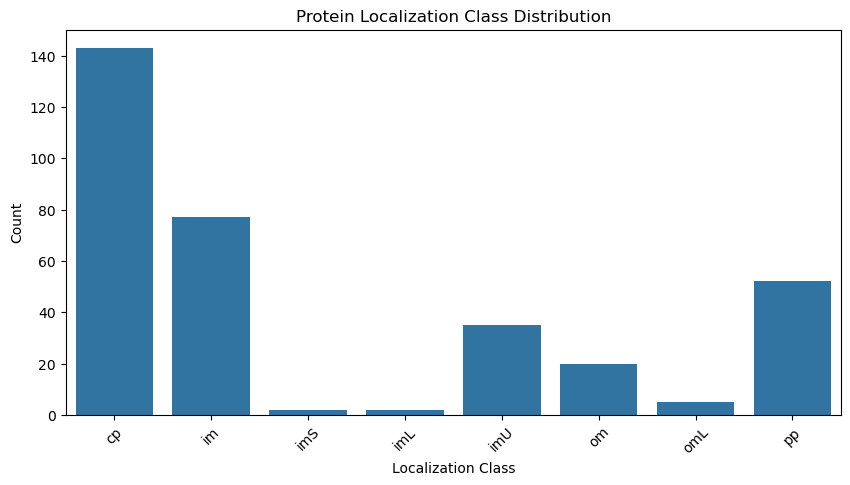

In [49]:

plt.figure(figsize=(10,5))

sns.countplot(x='class', data=df)

plt.title('Protein Localization Class Distribution')
plt.xlabel('Localization Class')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()



## Correlation Heatmap

This heatmap shows relationships among predictor variables.


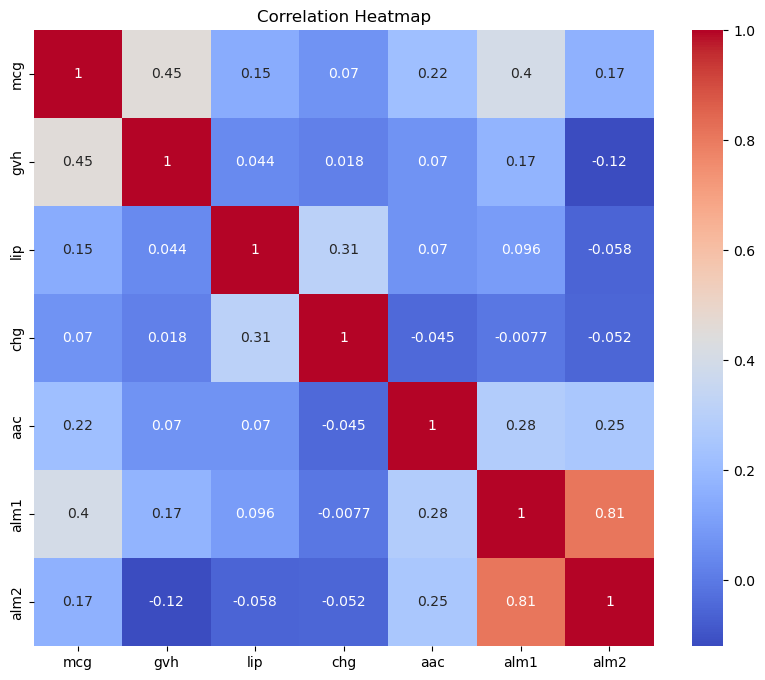

In [85]:

# Remove sequence name and class
features = df.drop(columns=['sequence_name', 'class'])

plt.figure(figsize=(10,8))

sns.heatmap(
    features.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()



## Boxplots Across Localization Classes

Boxplots help compare feature distributions across different protein localization sites.


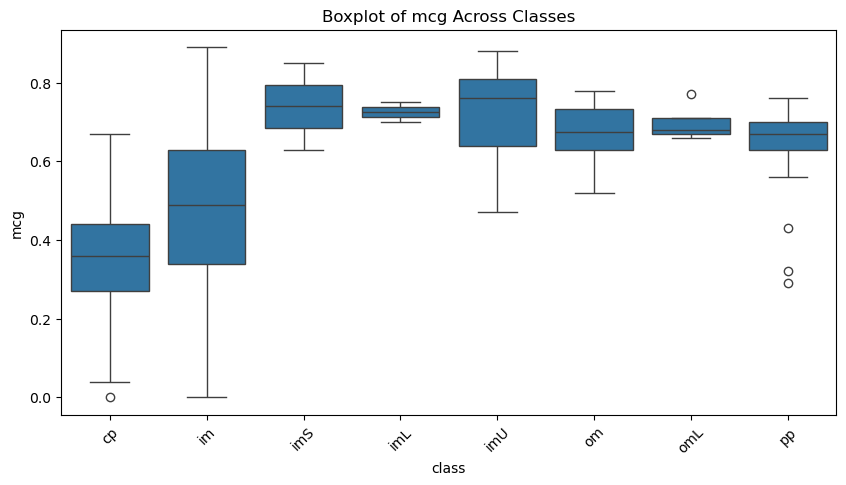

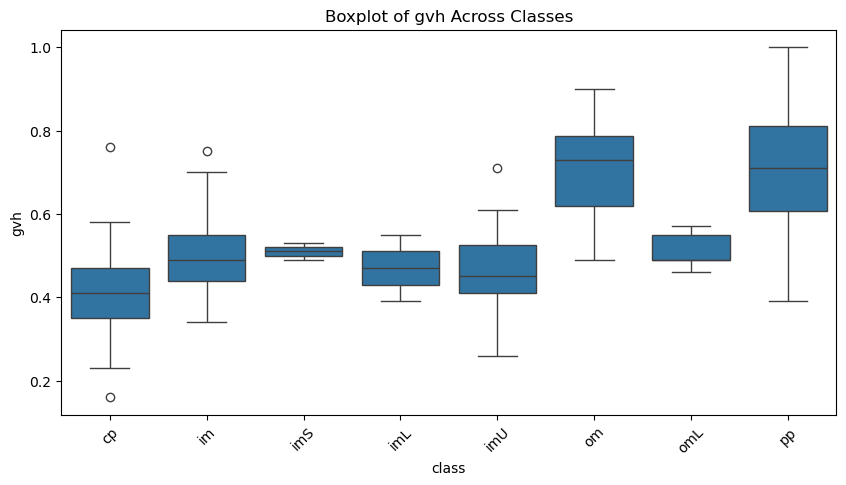

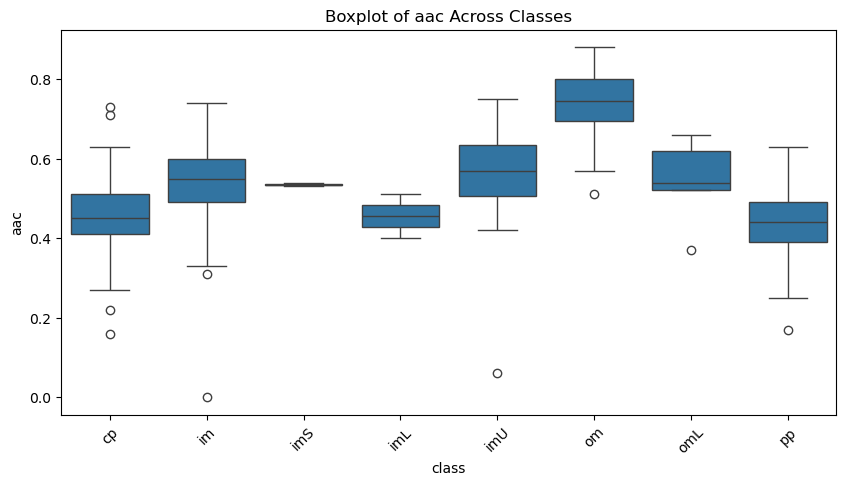

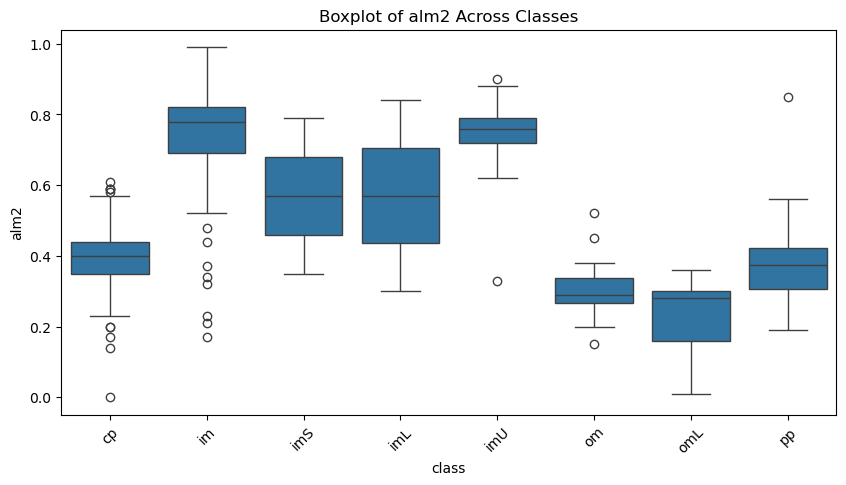

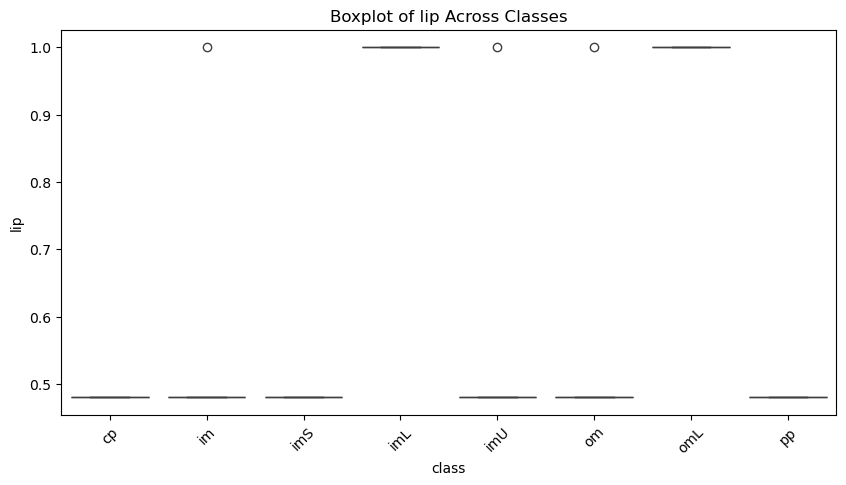

In [86]:

selected_features = ['mcg', 'gvh', 'aac', 'alm2', 'lip']

for feature in selected_features:
    
    plt.figure(figsize=(10,5))
    
    sns.boxplot(
        x='class',
        y=feature,
        data=df
    )
    
    plt.title(f'Boxplot of {feature} Across Classes')
    
    plt.xticks(rotation=45)
    
    plt.show()



# Data Preprocessing

We perform:
1. Feature scaling
2. Label encoding
3. Train-test split


In [87]:

# Prepare features and labels
X = df.drop(columns=['sequence_name', 'class'])
y = df['class']

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Standardization
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)

# Min-Max normalization
minmax_scaler = MinMaxScaler()
X_normalized = minmax_scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_standardized,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (268, 7)
Testing Shape: (68, 7)



# Random Forest Classification

Random Forest is a bagging-based ensemble learning algorithm.

Key ideas:
- Bootstrap sampling
- Multiple decision trees
- Random feature selection
- Majority voting


In [53]:

# Define parameter grid
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

# Initialize Random Forest
rf_model = RandomForestClassifier(
    random_state=42,
    oob_score=True
)

# Grid Search
rf_grid = GridSearchCV(
    rf_model,
    rf_params,
    cv=5,
    scoring='f1_weighted'
)

# Train model
rf_grid.fit(X_train, y_train)

# Best model
best_rf = rf_grid.best_estimator_

print("Best Parameters:", rf_grid.best_params_)
print("OOB Score:", best_rf.oob_score_)


Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 100}
OOB Score: 0.8544776119402985



## Random Forest Evaluation


In [58]:

# Predictions
rf_predictions = best_rf.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_predictions)

# F1 Score
rf_f1 = f1_score(
    y_test,
    rf_predictions,
    average='weighted'
)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1 Score:", rf_f1)

# Classification Report
print("\nClassification Report")
print(
    classification_report(
        y_test,
        rf_predictions,
        # target_names=label_encoder.classes_
    )
)


Random Forest Accuracy: 0.8676470588235294
Random Forest F1 Score: 0.8714426270061993

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.83      0.62      0.71        16
           4       0.50      0.86      0.63         7
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         1
           7       1.00      0.82      0.90        11

    accuracy                           0.87        68
   macro avg       0.88      0.88      0.87        68
weighted avg       0.90      0.87      0.87        68



In [66]:
print(rf_predictions)

from collections import Counter
print("Prediction Class Distribution:", Counter(rf_predictions))

print(len(Counter(rf_predictions)))

[0 7 4 0 7 1 4 1 4 4 0 4 0 1 4 7 0 7 6 1 0 0 1 5 0 0 0 4 1 4 0 0 0 4 0 0 0
 0 0 7 0 0 1 0 5 7 7 1 0 5 4 4 1 1 0 7 1 0 7 0 0 1 0 5 0 4 0 0]
Prediction Class Distribution: Counter({np.int64(0): 30, np.int64(4): 12, np.int64(1): 12, np.int64(7): 9, np.int64(5): 4, np.int64(6): 1})
6


In [68]:
print(Counter(y_test))

Counter({np.int64(0): 29, np.int64(1): 16, np.int64(7): 11, np.int64(4): 7, np.int64(5): 4, np.int64(6): 1})


In [67]:
print(label_encoder.classes_) 

['cp' 'im' 'imL' 'imS' 'imU' 'om' 'omL' 'pp']


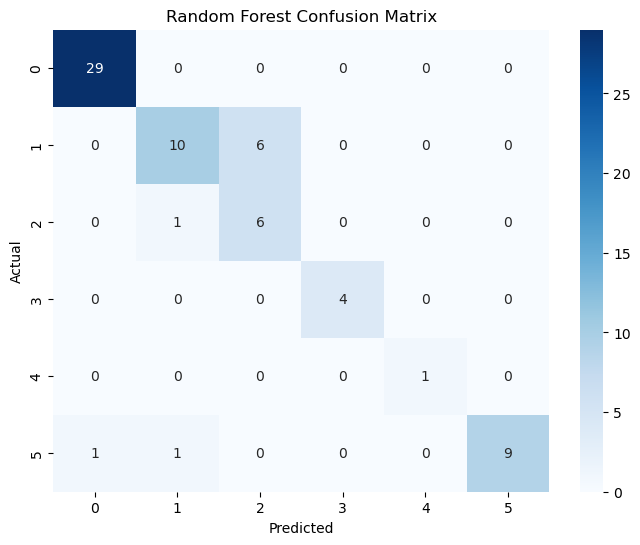

In [59]:

# Confusion Matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()



# XGBoost Classification

XGBoost is a gradient boosting algorithm.

Key ideas:
- Sequential learning
- Error correction
- Gradient optimization


In [60]:

# Initialize XGBoost model
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=len(np.unique(y_encoded)),
    eval_metric='mlogloss',
    random_state=42
)

# Parameter grid
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'gamma': [0, 1]
}

# Grid Search
xgb_grid = GridSearchCV(
    xgb_model,
    xgb_params,
    cv=3,
    scoring='f1_weighted'
)

# Train model
xgb_grid.fit(X_train, y_train)

# Best model
best_xgb = xgb_grid.best_estimator_

print("Best Parameters:", xgb_grid.best_params_)


Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3}


In [98]:

# Predictions
xgb_predictions = best_xgb.predict(X_test)

# Accuracy
xgb_accuracy = accuracy_score(y_test, xgb_predictions)

# F1 Score
xgb_f1 = f1_score(
    y_test,
    xgb_predictions,
    average='weighted'
)

print("XGBoost Accuracy:", xgb_accuracy)
print("XGBoost F1 Score:", xgb_f1)

# Classification Report
print("\nClassification Report")
print(
    classification_report(
        y_test,
        xgb_predictions,
        # target_names=label_encoder.classes_
    )
)


XGBoost Accuracy: 0.8823529411764706
XGBoost F1 Score: 0.8856288278023073

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        29
           1       0.92      0.69      0.79        16
           3       0.00      0.00      0.00         0
           4       0.55      0.86      0.67         7
           5       1.00      1.00      1.00         4
           6       0.00      0.00      0.00         1
           7       1.00      0.91      0.95        11

    accuracy                           0.88        68
   macro avg       0.63      0.64      0.63        68
weighted avg       0.90      0.88      0.89        68



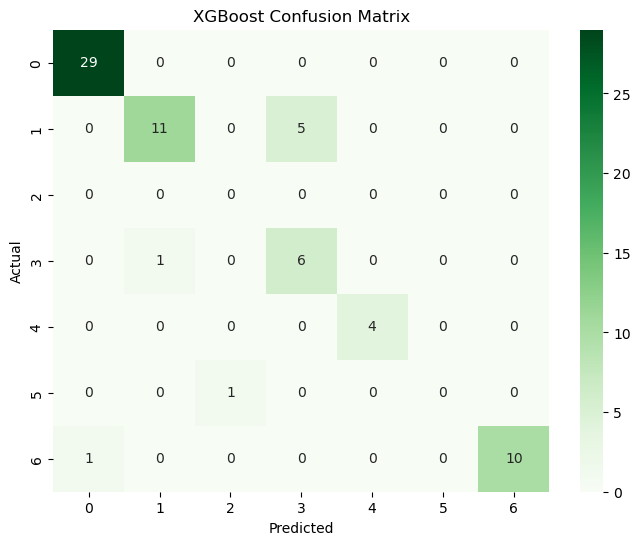

In [103]:

# Confusion Matrix
xgb_cm = confusion_matrix(y_test, xgb_predictions)

plt.figure(figsize=(8,6))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()



# Comparative Evaluation

We compare:
- Accuracy
- F1-score
- Feature importance


In [101]:

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_accuracy, xgb_accuracy],
    'F1 Score': [rf_f1, xgb_f1]
})

comparison


,Model,Accuracy,F1 Score
0,Random Forest,0.867647,0.871443
1,XGBoost,0.882353,0.885629



# Feature Importance Analysis

Feature importance helps identify biological variables contributing most strongly to protein localization prediction.


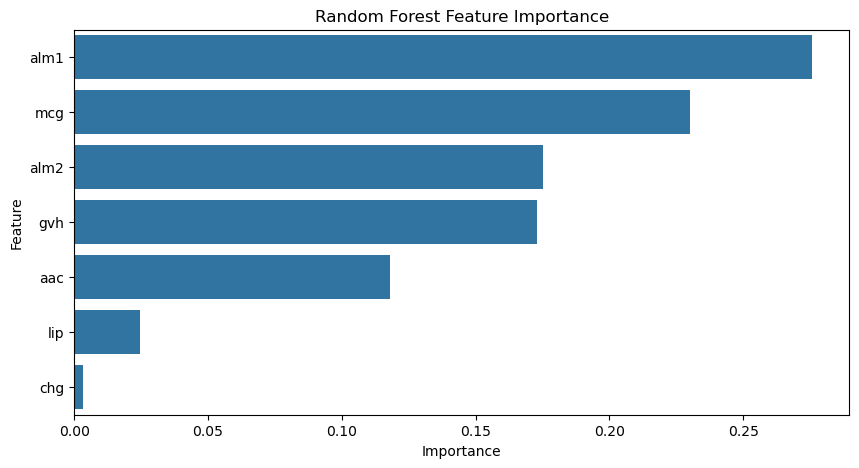

  Feature  Importance
5    alm1    0.275753
0     mcg    0.229922
6    alm2    0.175257
1     gvh    0.173075
4     aac    0.118144
2     lip    0.024712
3     chg    0.003138


In [64]:

# Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=rf_importance
)

plt.title('Random Forest Feature Importance')

plt.show()

print(rf_importance)


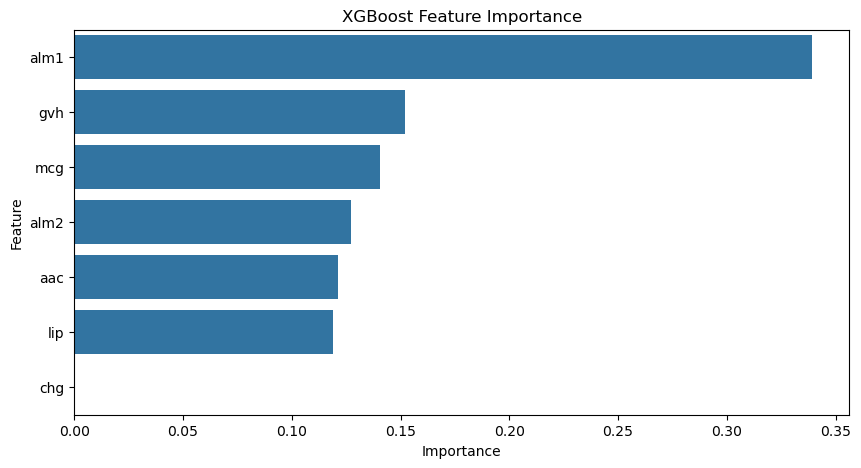

  Feature  Importance
5    alm1    0.339243
1     gvh    0.151930
0     mcg    0.140793
6    alm2    0.127448
4     aac    0.121397
2     lip    0.119188
3     chg    0.000000


In [102]:

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=xgb_importance
)

plt.title('XGBoost Feature Importance')

plt.show()

print(xgb_importance)



# Scientific Discussion

## Random Forest
Random Forest uses bagging and bootstrap aggregation to reduce variance and improve prediction stability. Random feature selection helps avoid overfitting and improves biological classification performance.

## XGBoost
XGBoost uses gradient boosting, where models are trained sequentially to correct previous errors. This often improves predictive accuracy for complex biological relationships.

## Biological Interpretation
Features with higher importance values contribute more strongly to localization prediction. These variables may represent biological signals associated with membrane transport, protein charge, and amino acid composition.

## Conclusion
Both Random Forest and XGBoost are powerful ensemble learning methods for bioinformatics classification tasks. XGBoost often achieves higher predictive performance, while Random Forest provides robust and interpretable results.
